In [2]:
import pandas as pd

# =========================
# 1. 데이터 불러오기
# =========================
file_path = "/content/drive/MyDrive/시계열 금융/시장금리(월,분기,년)_21204022.csv"
raw = pd.read_csv(file_path)

# =========================
# 2. 필요한 행만 추출
# =========================
gov = raw[raw["계정항목"] == "국고채(3년)"]
bbb = raw[raw["계정항목"] == "회사채(3년, BBB-)"]
aa  = raw[raw["계정항목"] == "회사채(3년, AA-)"]  # (선택)

# =========================
# 3. 날짜 컬럼만 정리
# =========================
date_cols = raw.columns[4:]  # 앞의 메타컬럼 제외

gov_ts = gov[date_cols].T
bbb_ts = bbb[date_cols].T
aa_ts  = aa[date_cols].T

gov_ts.columns = ["GOV3Y"]
bbb_ts.columns = ["BBB"]
aa_ts.columns  = ["AA"]

# 날짜 인덱스 변환
gov_ts.index = pd.to_datetime(gov_ts.index, format="%Y/%m")
bbb_ts.index = pd.to_datetime(bbb_ts.index, format="%Y/%m")
aa_ts.index  = pd.to_datetime(aa_ts.index, format="%Y/%m")

# =========================
# 4. 하나의 데이터프레임으로 결합
# =========================
df = pd.concat([gov_ts, bbb_ts, aa_ts], axis=1)

# =========================
# 5. 정크본드 스프레드 계산
# =========================
df["JunkSpread"] = df["BBB"] - df["GOV3Y"]

# (선택) 순수 신용 스프레드
df["CreditSpread_BBB_AA"] = df["BBB"] - df["AA"]

# =========================
# 6. 결과 확인
# =========================
print(df.head())

# =========================
# 7. 저장
# =========================
df.to_csv("junk_bond_spread_monthly.csv")


            GOV3Y     BBB     AA  JunkSpread  CreditSpread_BBB_AA
2023-01-01  3.460  10.788  4.704       7.328                6.084
2023-02-01  3.470  10.631  4.274       7.161                6.357
2023-03-01  3.461  10.595  4.184       7.134                6.411
2023-04-01  3.263  10.458  4.072       7.195                6.386
2023-05-01  3.330  10.524  4.139       7.194                6.385


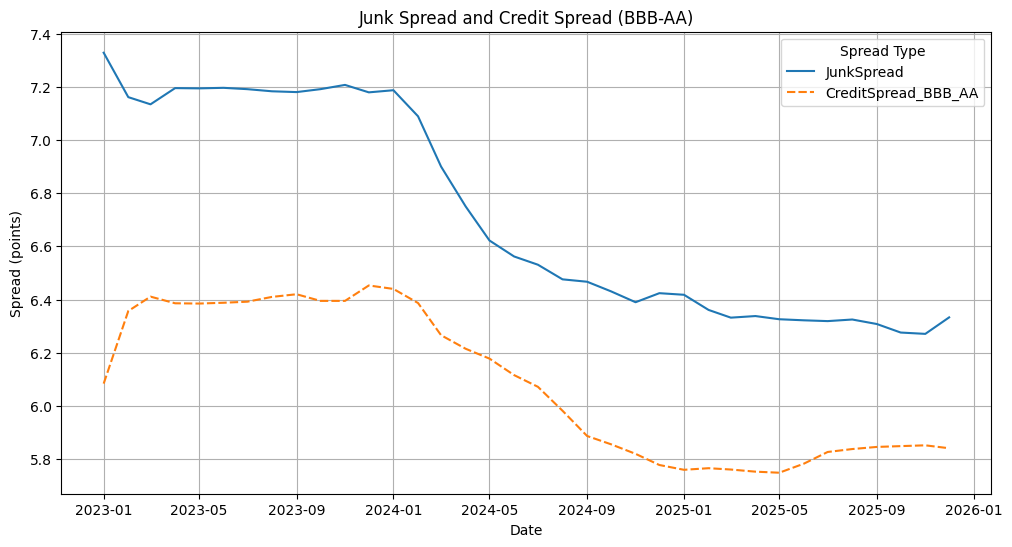

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(data=df[['JunkSpread', 'CreditSpread_BBB_AA']])
plt.title('Junk Spread and Credit Spread (BBB-AA)')
plt.xlabel('Date')
plt.ylabel('Spread (points)')
plt.grid(True)
plt.legend(title='Spread Type')
plt.show()

In [7]:
import pandas as pd
df_saved = pd.read_csv('junk_bond_spread_monthly.csv', index_col=0, parse_dates=True)
display(df_saved.head())

,GOV3Y,BBB,AA,JunkSpread,CreditSpread_BBB_AA
2023-01-01,3.460,10.788,4.704,7.328,6.084
2023-02-01,3.470,10.631,4.274,7.161,6.357
2023-03-01,3.461,10.595,4.184,7.134,6.411
2023-04-01,3.263,10.458,4.072,7.195,6.386
2023-05-01,3.330,10.524,4.139,7.194,6.385


In [8]:
from google.colab import files

# 'junk_bond_spread_monthly.csv' 파일을 로컬 컴퓨터로 다운로드합니다.
files.download('junk_bond_spread_monthly.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>